# Labour Force Data
Labour force status for adults with disabilities by disability type: https://open.canada.ca/data/en/dataset/92aeb8dc-c7ca-4f44-81df-fdaf289d23fd 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

labour_force = pd.read_csv("../data/raw/labour_force/13100348.csv")
labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Total labour force,Number,223,units,0,v91886462,1.1.1.1.1.1,2338240.0,NaN,NaN,NaN,0
1,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Employed,Number,223,units,0,v91886463,1.1.1.1.1.2,1026910.0,NaN,NaN,NaN,0
2,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Unemployed,Number,223,units,0,v91886464,1.1.1.1.1.3,137450.0,NaN,NaN,NaN,0
3,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Not in labour force,Number,223,units,0,v91886465,1.1.1.1.1.4,1007660.0,NaN,NaN,NaN,0
4,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Participation rate,Percent,239,units,0,v91886466,1.1.1.1.1.5,53.6,NaN,NaN,NaN,1


In [5]:
labour_force.tail()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
151195,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized participation rate,Percent,239,units,0,v92037657,14.3.6.12.5.6,NaN,F,NaN,NaN,1
151196,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Employment Rate,Percent,239,units,0,v92037658,14.3.6.12.5.7,NaN,F,NaN,NaN,1
151197,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized employment rate,Percent,239,units,0,v92037659,14.3.6.12.5.8,NaN,F,NaN,NaN,1
151198,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Unemployment rate,Percent,239,units,0,v92037660,14.3.6.12.5.9,NaN,F,NaN,NaN,1
151199,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized unemployment rate,Percent,239,units,0,v92037661,14.3.6.12.5.10,NaN,F,NaN,NaN,1


In [3]:
labour_force.shape

(151200, 19)

In [4]:
labour_force.info()

<class 'pandas.DataFrame'>
RangeIndex: 151200 entries, 0 to 151199
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   REF_DATE             151200 non-null  int64  
 1   GEO                  151200 non-null  str    
 2   DGUID                151200 non-null  str    
 3   Sex                  151200 non-null  str    
 4   Age group            151200 non-null  str    
 5   Disability type      151200 non-null  str    
 6   Global Severity      151200 non-null  str    
 7   Labour force status  151200 non-null  str    
 8   UOM                  151200 non-null  str    
 9   UOM_ID               151200 non-null  int64  
 10  SCALAR_FACTOR        151200 non-null  str    
 11  SCALAR_ID            151200 non-null  int64  
 12  VECTOR               151200 non-null  str    
 13  COORDINATE           151200 non-null  str    
 14  VALUE                34597 non-null   float64
 15  STATUS               136535 

In [29]:
# keep relevant attributes
clean_labour_force = labour_force[[
    'GEO', 
    'Sex', 
    'Age group', 
    'Disability type', 
    'Global Severity', 
    'Labour force status',
    'UOM',
    'STATUS']]

clean_labour_force.head()

,GEO,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,STATUS
0,Canada,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Total labour force,Number,NaN
1,Canada,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Employed,Number,NaN
2,Canada,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Unemployed,Number,NaN
3,Canada,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Not in labour force,Number,NaN
4,Canada,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Participation rate,Percent,NaN


In [23]:
# Symbol legend: E use with caution, F too unreliable to be published
labour_force['STATUS'].unique()

<StringArray>
[nan, 'E', 'F']
Length: 3, dtype: str

In [18]:
# only keep UOM = 'Number'
labour_force['UOM'].unique()

<StringArray>
['Number', 'Percent']
Length: 2, dtype: str

In [13]:
labour_force['Age group'].unique()

<StringArray>
['Total, 15 to 64 years',        '15 to 24 years',        '25 to 34 years',
        '35 to 44 years',        '45 to 54 years',        '55 to 64 years']
Length: 6, dtype: str

In [14]:
labour_force['Disability type'].unique()

<StringArray>
[       'All disability types',                      'Seeing',
                     'Hearing',                    'Mobility',
                 'Flexibility',                   'Dexterity',
                        'Pain',                    'Learning',
                      'Memory',               'Developmental',
 'Mental and/or psychological',     'Unknown disability type']
Length: 12, dtype: str

In [15]:
labour_force['Global Severity'].unique()

<StringArray>
['Total population, severity of disability',
                                     'Mild',
                                 'Moderate',
                                   'Severe',
                              'Very Severe']
Length: 5, dtype: str

In [ ]:
# Filter for the specific demographic intersection
# We want: Mobility disability, Severe severity, Ages 25-34
target_group = df[
    (df['Disability type'] == 'Mobility') &
    (df['Global Severity'] == 'Severe') &
    (df['Age group'] == '25 to 34 years') # Verify the exact string in your data using df['Age group'].unique()
]

Labour Force Status: Severe Mobility Disability (Ages 25-34)
--------------------------------------------------
Sex                                  Both sexes  Females   Males
Labour force status                                             
Age standardized employment rate          165.8     28.3    73.3
Age standardized participation rate       259.6     36.9    79.8
Age standardized unemployment rate          0.0      0.0     0.0
Employed                                10180.0   4040.0     0.0
Employment Rate                           165.9     28.3    73.4
Not in labour force                     10690.0   9000.0     0.0
Participation rate                        259.8     36.9    79.8
Total labour force                      43040.0  25140.0  8450.0
Unemployed                                  0.0      0.0     0.0
Unemployment rate                           0.0      0.0     0.0

Calculated Employment Rate:
Both sexes: 15.7%
Females: 10.5%
Males: 0.0%


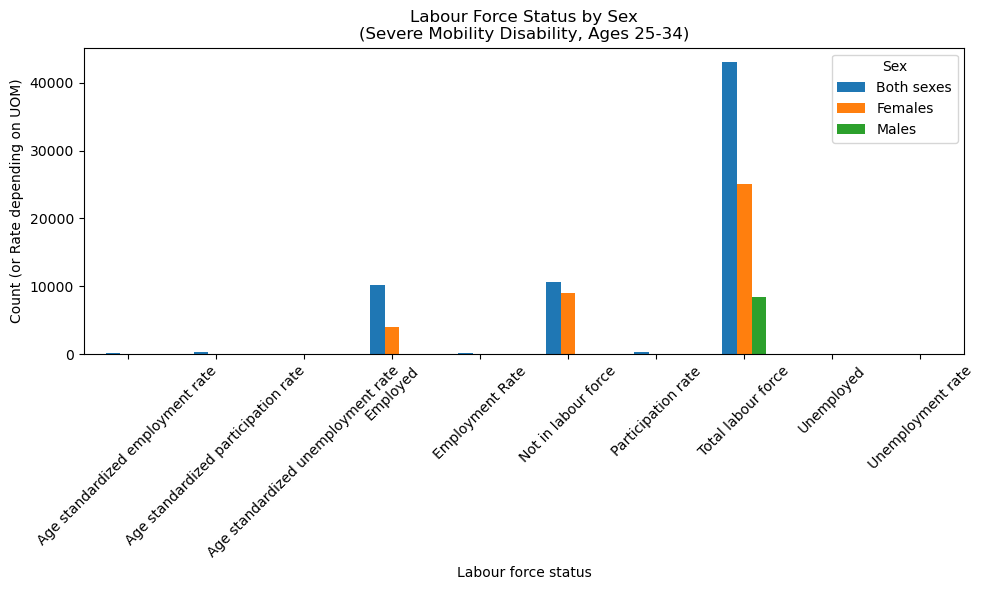

In [7]:
# 1. Load the data
df = labour_force

# 2. Filter for the specific demographic intersection
# We want: Mobility disability, Severe severity, Ages 25-34
target_group = df[
    (df['Disability type'] == 'Mobility') &
    (df['Global Severity'] == 'Severe') &
    (df['Age group'] == '25 to 34 years') # Verify the exact string in your data using df['Age group'].unique()
]

# 3. Pivot the data to compare Men and Women side-by-side
# We want to see the Labour force status (Employed, Unemployed, etc.) as the metric
comparison_df = target_group.pivot_table(
    index='Labour force status', 
    columns='Sex', 
    values='VALUE', 
    aggfunc='sum' # Assuming the value is a count; use 'mean' if it is a rate
)

# 4. Display the table
print("Labour Force Status: Severe Mobility Disability (Ages 25-34)")
print("-" * 50)
print(comparison_df)

# 5. Calculate Employment Rate specifically
# Formula: Employed / (Employed + Unemployed + Not in labour force)
# Note: You may need to adjust this depending on the exact categories in the 'Labour force status' column
if 'Employed' in comparison_df.index:
    rates = {}
    for sex in comparison_df.columns:
        employed = comparison_df.loc['Employed', sex]
        total = comparison_df[sex].sum() 
        rates[sex] = (employed / total) * 100 if total > 0 else 0
        
    print("\nCalculated Employment Rate:")
    for sex, rate in rates.items():
        print(f"{sex}: {rate:.1f}%")

# 6. Basic Visualization
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Labour Force Status by Sex\n(Severe Mobility Disability, Ages 25-34)')
plt.ylabel('Count (or Rate depending on UOM)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()